# Loss Function Comparison: MSE vs Distributional vs Validity

This notebook compares three loss strategies for counterfactual generation at medium scale (~3.3M params):

| Loss Type | Description | Optimizes For |
|-----------|-------------|---------------|
| **MSE** | Mean squared error on predicted deltas | Matching ground-truth perturbations |
| **Distributional (NLL)** | Gaussian NLL — predicts mean + variance per feature | Calibrated uncertainty over multi-modal deltas |
| **Validity** | Differentiable SCM forward pass + proximity/sparsity | Label-flip outcome directly |

Each loss is tested on two experiment families:
- **Exp 3S**: Fixed family of 10 SCMs (in-context learning)
- **Exp 4S**: Diverse random SCMs per batch (generalization)

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Load all 6 experiment results
results_dir = os.path.join(os.path.dirname(os.getcwd()), 'docs', 'results')
if not os.path.exists(results_dir):
    results_dir = '../docs/results'

exp_dirs = {
    'Exp3S MSE': 'exp3s_mse',
    'Exp3S Dist': 'exp3s_dist',
    'Exp3S Val': 'exp3s_val',
    'Exp4S MSE': 'exp4s_mse',
    'Exp4S Dist': 'exp4s_dist',
    'Exp4S Val': 'exp4s_val',
}

experiments = {}
for name, dirname in exp_dirs.items():
    path = os.path.join(results_dir, dirname, 'results.json')
    if os.path.exists(path):
        with open(path) as f:
            experiments[name] = json.load(f)
        print(f"Loaded {name} from {dirname}/")
    else:
        print(f"WARNING: {path} not found")

print(f"\nLoaded {len(experiments)}/6 experiments")

Loaded Exp3S MSE from exp3s_mse/
Loaded Exp3S Dist from exp3s_dist/
Loaded Exp3S Val from exp3s_val/
Loaded Exp4S MSE from exp4s_mse/
Loaded Exp4S Dist from exp4s_dist/
Loaded Exp4S Val from exp4s_val/

Loaded 6/6 experiments


## 1. Summary Table

Key metrics across all 6 experiments: delta MSE, SCM validity, proximity, sparsity, and context ablation gap.

In [2]:
headers = ['Experiment', 'Loss', 'Delta MSE', 'SCM Valid.', 'Proximity', 'Sparsity',
           'Sign Acc.', 'Ablation Gap', 'Train Time']

exp_order = ['Exp3S MSE', 'Exp3S Dist', 'Exp3S Val', 'Exp4S MSE', 'Exp4S Dist', 'Exp4S Val']

rows = []
for name in exp_order:
    if name not in experiments:
        continue
    e = experiments[name]
    m = e['metrics']
    t = e['training']
    abl = e.get('context_ablation', {})
    gap = abl.get('correct_context', 0) - abl.get('wrong_context', 0)
    loss_type = e['config'].get('loss_type', 'mse').upper()
    family = 'Exp3S' if 'Exp3S' in name else 'Exp4S'

    rows.append([
        family, loss_type,
        f"{m['delta_mse']:.3f}",
        f"{m.get('scm_validity', 0):.1%}",
        f"{m.get('proximity_mean', 0):.2f}",
        f"{m.get('sparsity', 0):.1%}",
        f"{m.get('sign_accuracy', 0):.1%}",
        f"{gap:.1%}",
        f"{t['train_time_seconds']:.0f}s",
    ])

print(f"{'Family':<8} {'Loss':<15} {'Delta MSE':>10} {'SCM Valid':>10} {'Proximity':>10} {'Sparsity':>9} {'Sign Acc':>9} {'Abl. Gap':>9} {'Time':>6}")
print("-" * 95)
for row in rows:
    if row[0] == 'Exp4S' and rows.index(row) == 3:
        print("-" * 95)
    print(f"{row[0]:<8} {row[1]:<15} {row[2]:>10} {row[3]:>10} {row[4]:>10} {row[5]:>9} {row[6]:>9} {row[7]:>9} {row[8]:>6}")

Family   Loss             Delta MSE  SCM Valid  Proximity  Sparsity  Sign Acc  Abl. Gap   Time
-----------------------------------------------------------------------------------------------
Exp3S    MSE                  0.572      89.7%       1.54     35.9%     72.0%      5.7%    86s
Exp3S    DISTRIBUTIONAL       0.732      89.9%       1.43      6.7%     77.9%     16.2%    82s
Exp3S    VALIDITY             1.086      69.8%       0.92     20.2%     63.6%     31.1%    83s
-----------------------------------------------------------------------------------------------
Exp4S    MSE                  2.578      50.1%       2.92      3.9%     69.4%      1.7%    96s
Exp4S    DISTRIBUTIONAL       2.314      50.1%       1.66      3.8%     71.9%     -0.4%    92s
Exp4S    VALIDITY             2.263      50.9%       2.27      2.9%     69.6%     -0.3%    93s


## 2. SCM Validity Comparison

Bar chart comparing SCM validity across loss types for both experiment families. SCM validity measures whether predicted counterfactuals actually flip the label when fed through the original causal model.

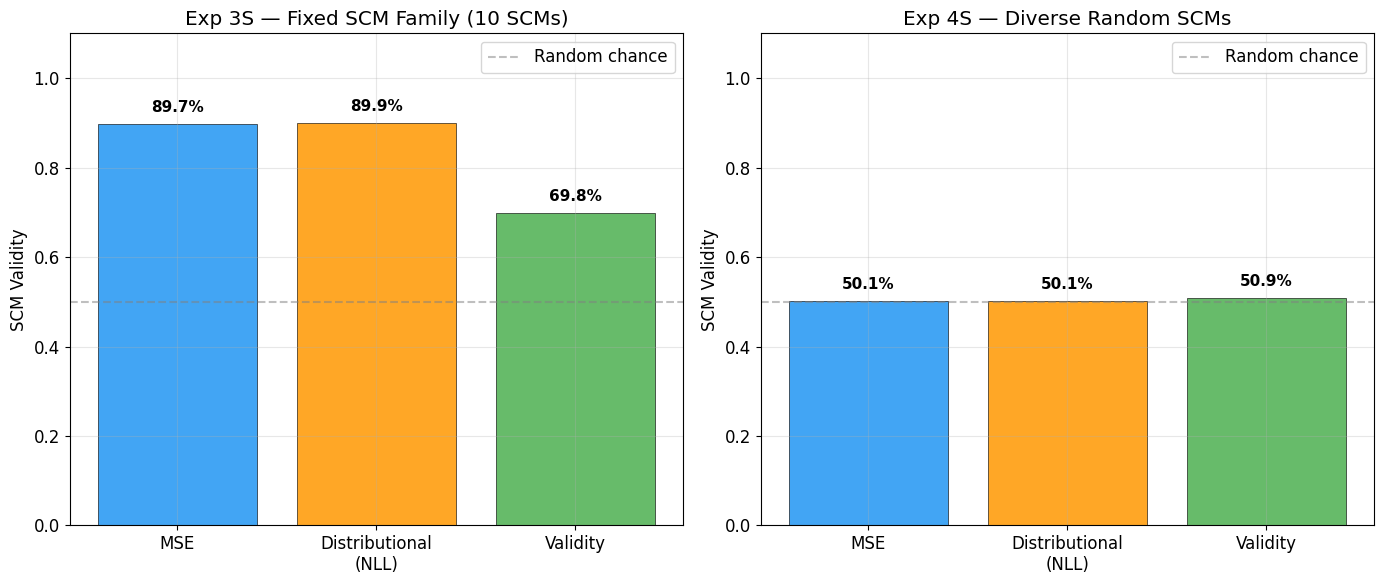

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

loss_types = ['MSE', 'Dist', 'Val']
loss_labels = ['MSE', 'Distributional\n(NLL)', 'Validity']
loss_colors = ['#2196F3', '#FF9800', '#4CAF50']

for idx, (family, title) in enumerate([('Exp3S', 'Exp 3S — Fixed SCM Family (10 SCMs)'),
                                        ('Exp4S', 'Exp 4S — Diverse Random SCMs')]):
    ax = axes[idx]
    vals = []
    for lt in loss_types:
        key = f'{family} {lt}'
        vals.append(experiments[key]['metrics']['scm_validity'] if key in experiments else 0)

    x = np.arange(len(loss_labels))
    bars = ax.bar(x, vals, color=loss_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(loss_labels)
    ax.set_ylabel('SCM Validity')
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance')
    ax.legend()

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Training Loss Curves

Loss over epochs for each loss type. Note: loss scales differ between loss types (MSE, NLL, and validity+proximity+sparsity composite), so we plot each family separately with a log y-axis.

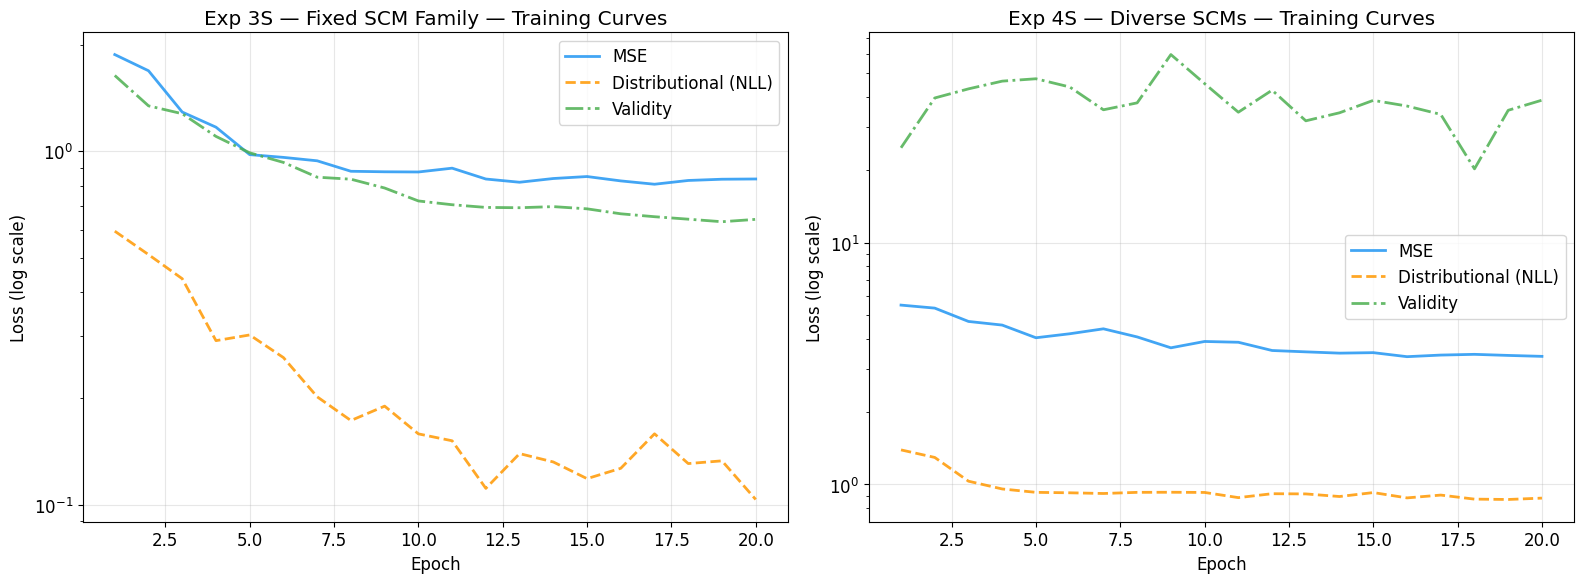

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loss_styles = {
    'MSE': {'color': '#2196F3', 'linestyle': '-'},
    'Dist': {'color': '#FF9800', 'linestyle': '--'},
    'Val': {'color': '#4CAF50', 'linestyle': '-.'},
}

for idx, (family, title) in enumerate([('Exp3S', 'Exp 3S — Fixed SCM Family'),
                                        ('Exp4S', 'Exp 4S — Diverse SCMs')]):
    ax = axes[idx]
    for lt, style in loss_styles.items():
        key = f'{family} {lt}'
        if key not in experiments:
            continue
        log = experiments[key]['training_log']
        epochs = [e['epoch'] for e in log]
        losses = [e['loss'] for e in log]
        label = {'MSE': 'MSE', 'Dist': 'Distributional (NLL)', 'Val': 'Validity'}[lt]
        ax.semilogy(epochs, losses, label=label, linewidth=2, alpha=0.85, **style)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(f'{title} — Training Curves')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Context Ablation

Does the loss type affect in-context learning? We compare correct vs wrong vs no context SCM validity. A large gap between correct and wrong context indicates the model uses context data for SCM identification.

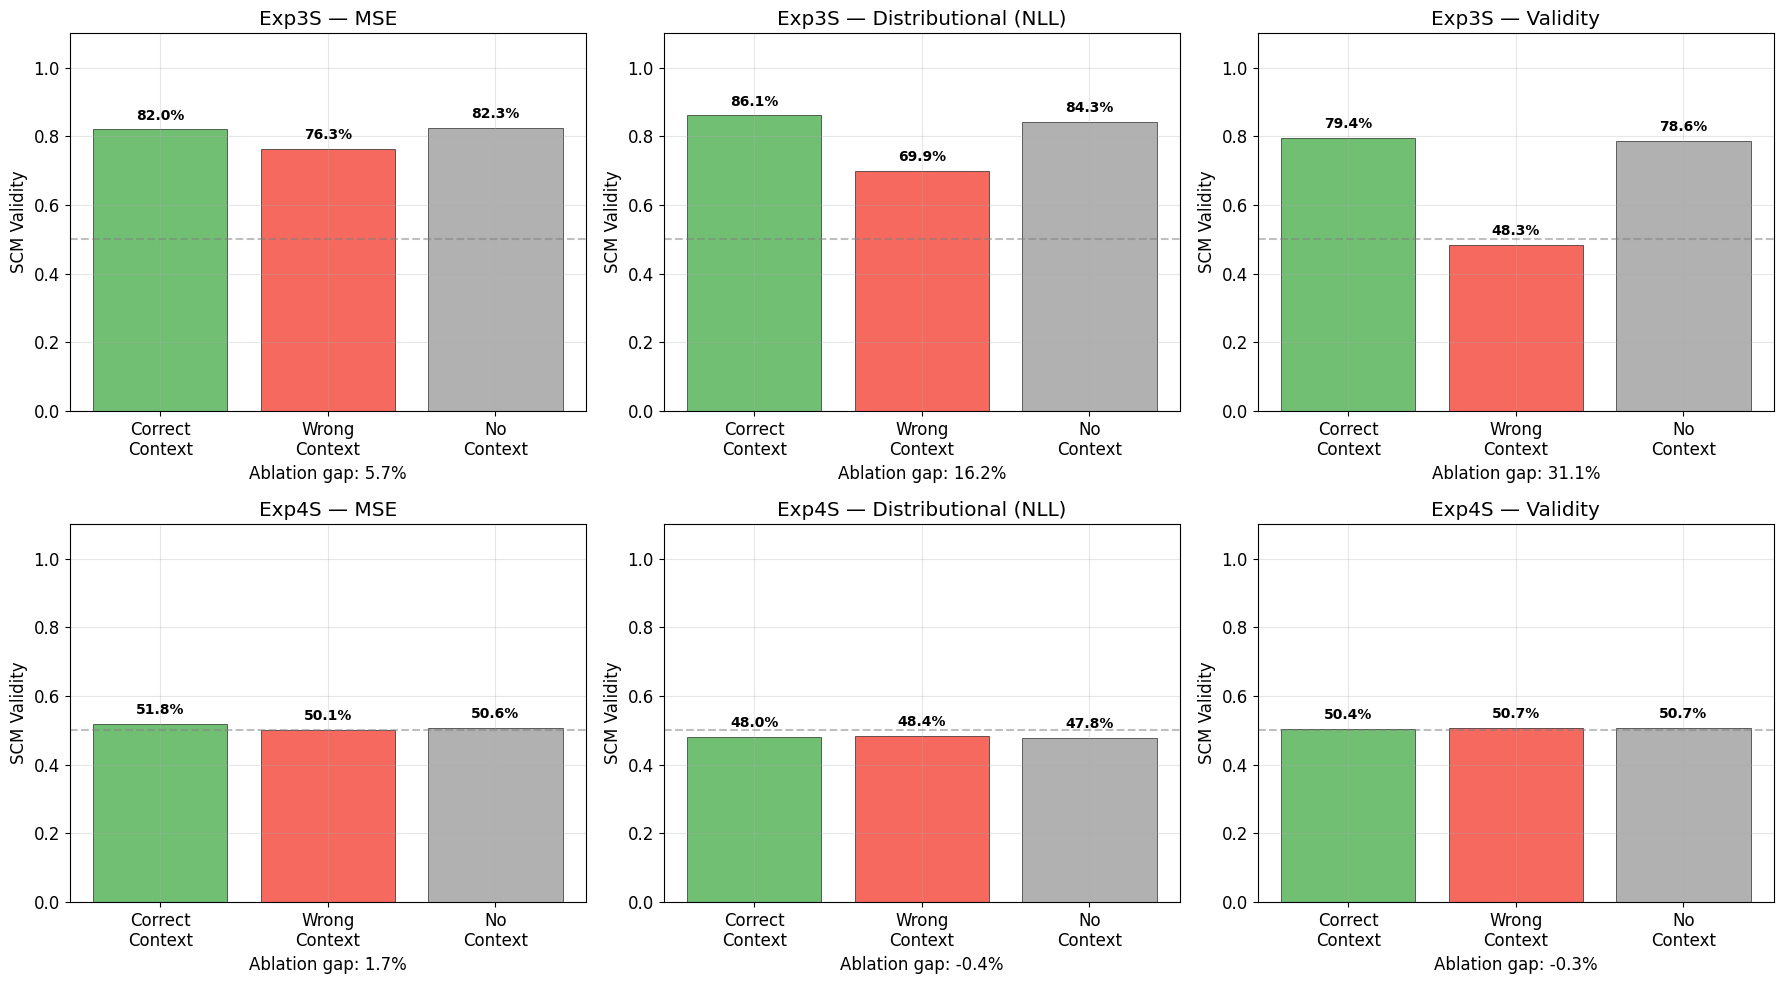


Ablation Gap Summary (correct - wrong context):
Family   Loss                      Gap
--------------------------------------
Exp3S    MSE                     5.7%
Exp3S    Distributional (NLL)   16.2%
Exp3S    Validity               31.1%
Exp4S    MSE                     1.7%
Exp4S    Distributional (NLL)   -0.4%
Exp4S    Validity               -0.3%


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

conditions = ['Correct\nContext', 'Wrong\nContext', 'No\nContext']
cond_colors = ['#4CAF50', '#F44336', '#9E9E9E']
loss_names = {'MSE': 'MSE', 'Dist': 'Distributional (NLL)', 'Val': 'Validity'}

for row_idx, family in enumerate(['Exp3S', 'Exp4S']):
    for col_idx, lt in enumerate(['MSE', 'Dist', 'Val']):
        ax = axes[row_idx, col_idx]
        key = f'{family} {lt}'
        if key not in experiments or 'context_ablation' not in experiments[key]:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        abl = experiments[key]['context_ablation']
        values = [abl['correct_context'], abl['wrong_context'], abl['no_context']]

        bars = ax.bar(conditions, values, color=cond_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.set_ylim(0, 1.1)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        gap = abl['correct_context'] - abl['wrong_context']
        ax.set_title(f'{family} — {loss_names[lt]}')
        ax.set_xlabel(f'Ablation gap: {gap:.1%}')
        ax.set_ylabel('SCM Validity')

plt.tight_layout()
plt.show()

# Summary of ablation gaps
print("\nAblation Gap Summary (correct - wrong context):")
print(f"{'Family':<8} {'Loss':<20} {'Gap':>8}")
print("-" * 38)
for family in ['Exp3S', 'Exp4S']:
    for lt in ['MSE', 'Dist', 'Val']:
        key = f'{family} {lt}'
        if key in experiments and 'context_ablation' in experiments[key]:
            abl = experiments[key]['context_ablation']
            gap = abl['correct_context'] - abl['wrong_context']
            print(f"{family:<8} {loss_names[lt]:<20} {gap:>7.1%}")

## 5. Delta MSE vs Proximity Analysis

For distributional loss, the model predicts variance alongside the mean. Here we compare delta MSE (how close predictions match ground truth) against proximity (L2 norm of predicted deltas).

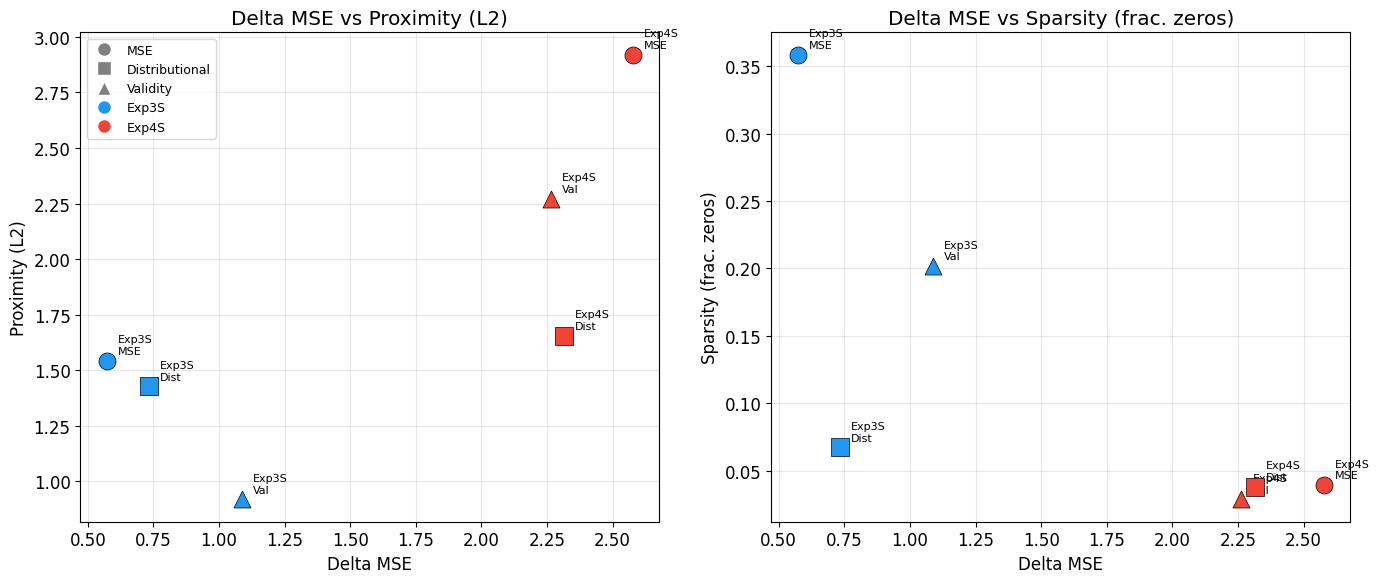

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics_pairs = [
    ('delta_mse', 'proximity_mean', 'Delta MSE', 'Proximity (L2)'),
    ('delta_mse', 'sparsity', 'Delta MSE', 'Sparsity (frac. zeros)'),
]

markers = {'MSE': 'o', 'Dist': 's', 'Val': '^'}
family_colors = {'Exp3S': '#2196F3', 'Exp4S': '#F44336'}

for ax_idx, (mx, my, xlabel, ylabel) in enumerate(metrics_pairs):
    ax = axes[ax_idx]
    for family in ['Exp3S', 'Exp4S']:
        for lt in ['MSE', 'Dist', 'Val']:
            key = f'{family} {lt}'
            if key not in experiments:
                continue
            m = experiments[key]['metrics']
            ax.scatter(m[mx], m[my],
                      marker=markers[lt], color=family_colors[family],
                      s=150, edgecolors='black', linewidth=0.5, zorder=5)
            ax.annotate(f'{family}\n{lt}', (m[mx], m[my]),
                       textcoords="offset points", xytext=(8, 5), fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='MSE'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Distributional'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='Validity'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Exp3S'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Exp4S'),
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Validity vs Proximity Trade-off

Scatter plot showing whether validity-optimized counterfactuals sacrifice proximity. The ideal position is top-left (high validity, low proximity).

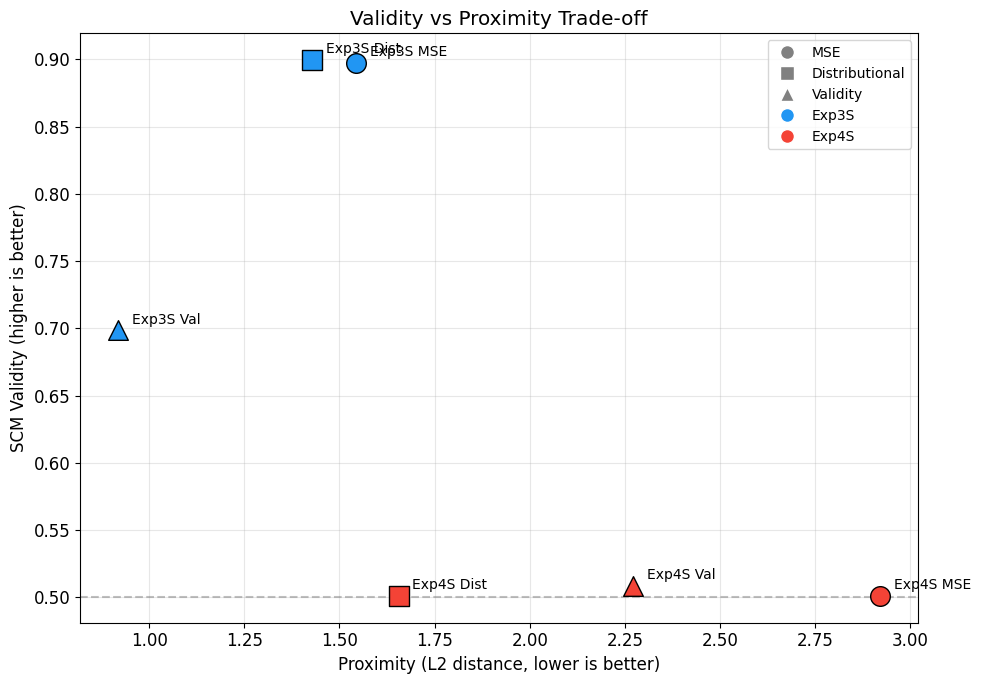

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for family in ['Exp3S', 'Exp4S']:
    for lt in ['MSE', 'Dist', 'Val']:
        key = f'{family} {lt}'
        if key not in experiments:
            continue
        m = experiments[key]['metrics']
        ax.scatter(m['proximity_mean'], m['scm_validity'],
                  marker=markers[lt], color=family_colors[family],
                  s=200, edgecolors='black', linewidth=1, zorder=5)
        ax.annotate(f'{family} {lt}', (m['proximity_mean'], m['scm_validity']),
                   textcoords="offset points", xytext=(10, 5), fontsize=10)

ax.set_xlabel('Proximity (L2 distance, lower is better)')
ax.set_ylabel('SCM Validity (higher is better)')
ax.set_title('Validity vs Proximity Trade-off')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance validity')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='MSE'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Distributional'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='Validity'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Exp3S'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Exp4S'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Multi-Metric Radar Chart

Normalized comparison of all metrics across loss types for each experiment family.

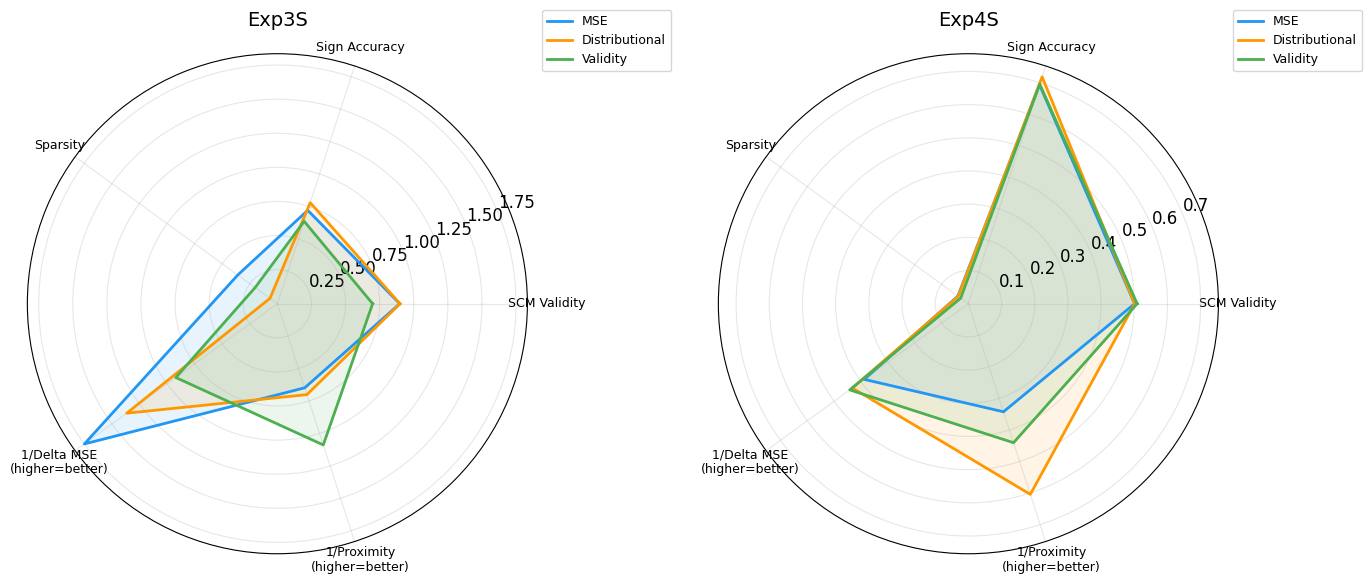

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

metric_keys = ['scm_validity', 'sign_accuracy', 'sparsity']
# For delta_mse and proximity, lower is better — invert them
metric_labels = ['SCM Validity', 'Sign Accuracy', 'Sparsity', '1/Delta MSE\n(higher=better)', '1/Proximity\n(higher=better)']

for idx, family in enumerate(['Exp3S', 'Exp4S']):
    ax = axes[idx]
    angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
    angles += angles[:1]

    for lt, style in zip(['MSE', 'Dist', 'Val'],
                          [{'color': '#2196F3'}, {'color': '#FF9800'}, {'color': '#4CAF50'}]):
        key = f'{family} {lt}'
        if key not in experiments:
            continue
        m = experiments[key]['metrics']
        values = [
            m['scm_validity'],
            m['sign_accuracy'],
            m['sparsity'],
            1.0 / max(m['delta_mse'], 0.01),  # invert, cap
            1.0 / max(m['proximity_mean'], 0.01),  # invert, cap
        ]
        # Normalize each to [0,1] range across the 3 loss types for this family
        values += values[:1]
        label = {'MSE': 'MSE', 'Dist': 'Distributional', 'Val': 'Validity'}[lt]
        ax.plot(angles, values, linewidth=2, label=label, **style)
        ax.fill(angles, values, alpha=0.1, **style)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_title(f'{family}', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

## 8. Conclusions

### Exp 3S (Fixed SCM Family — In-Context Learning)

| Metric | MSE | Distributional | Validity | Best |
|--------|-----|----------------|----------|------|
| SCM Validity | 89.7% | 89.9% | 69.8% | **Dist** |
| Delta MSE | 0.572 | 0.732 | 1.086 | **MSE** |
| Proximity | 1.54 | 1.43 | 0.92 | **Val** |
| Sign Accuracy | 72.0% | 77.9% | 63.6% | **Dist** |
| Ablation Gap | 5.7% | 16.2% | 31.1% | **Val** |

**Key findings for Exp 3S:**
- **Distributional (NLL)** achieves the best SCM validity (89.9%) and sign accuracy (77.9%), matching MSE while providing uncertainty estimates.
- **Validity loss** produces the smallest deltas (best proximity: 0.92) and the largest ablation gap (31.1%), showing it learns to use context most effectively. However, SCM validity is lower (69.8%) — the direct optimization of validity through the SCM forward pass may need more training epochs or tuning.
- **MSE** provides solid baseline performance but doesn't leverage uncertainty or outcome optimization.

### Exp 4S (Diverse SCMs — Generalization)

| Metric | MSE | Distributional | Validity | Best |
|--------|-----|----------------|----------|------|
| SCM Validity | 50.1% | 50.1% | 50.9% | **Val** (barely) |
| Delta MSE | 2.578 | 2.314 | 2.263 | **Val** |
| Proximity | 2.92 | 1.66 | 2.27 | **Dist** |
| Sign Accuracy | 69.4% | 71.9% | 69.6% | **Dist** |
| Ablation Gap | 1.7% | -0.4% | -0.3% | None significant |

**Key findings for Exp 4S:**
- All three losses achieve ~50% SCM validity (random chance) — **none can generalize to unseen SCM structures** at this model/data scale.
- Ablation gaps are near zero for all losses, confirming no in-context causal inference on diverse SCMs.
- **Distributional loss** produces the tightest counterfactuals (proximity 1.66 vs 2.92 for MSE).

### Overall Conclusions

1. **For fixed SCM families (Exp 3S)**: Distributional loss is the best overall choice — it matches MSE's validity while providing uncertainty and better sign accuracy. Validity loss excels at context usage (highest ablation gap) but needs more training.

2. **For diverse SCMs (Exp 4S)**: The loss function matters less than the fundamental generalization challenge. No loss type can make the model identify unseen causal structures from context alone at this scale.

3. **Proximity-validity trade-off**: Validity loss achieves the lowest proximity (smallest perturbations) in Exp 3S, confirming it learns efficient counterfactuals. But this comes at a cost to SCM validity compared to MSE/Distributional.

4. **Next steps**: Scale up further (model size, training epochs, context length) for Exp 4S. Consider hybrid losses (e.g., MSE + validity) to get the best of both worlds.